# Predicting Implied Volatility and Options Pricing Analysis
### Using S&P500-2021 Dataset and Random Forest Regression

In [252]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [284]:
# Import dataset
# Reading first 40000 rows (data from 2020)
data = pd.read_csv('spy_2020_2022.csv', engine='python', nrows=40000)

data.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [285]:
# Remove punctuation from column names

new_column_names = {}
for i in range(len(data.columns)):
    new_column_names[data.columns[i]] = data.columns[i].lower().replace('[', '').replace(']','').replace(' ', '')

data.rename(columns=new_column_names, inplace= True)
data.columns

Index(['quote_unixtime', 'quote_readtime', 'quote_date', 'quote_time_hours',
       'underlying_last', 'expire_date', 'expire_unix', 'dte', 'c_delta',
       'c_gamma', 'c_vega', 'c_theta', 'c_rho', 'c_iv', 'c_volume', 'c_last',
       'c_size', 'c_bid', 'c_ask', 'strike', 'p_bid', 'p_ask', 'p_size',
       'p_last', 'p_delta', 'p_gamma', 'p_vega', 'p_theta', 'p_rho', 'p_iv',
       'p_volume', 'strike_distance', 'strike_distance_pct'],
      dtype='object')

In [286]:
data.shape

(40000, 33)

In [287]:
# Creating the final full dataset by dropping redundant columns / leakage 
# 1. c_last, c_bid, c_ask are prices used to compute the c_iv - leakage
# 2. c_size, 'quote_readtime', 'quote_date', 'quote_time_hours', 'quote_unixtime', 'expire_unix' - Redundant metadata
# 3. IMPORTANT - We will drop all Put option features since this model will focus on call options

dataset = data.drop(['c_last', 'c_bid', 'c_ask', 'c_size',
                           'expire_unix', 'quote_readtime', 'quote_date', 'quote_time_hours', 'quote_unixtime',
                          'p_bid', 'p_ask', 'p_size', 'p_last', 'p_delta', 'p_gamma', 'p_vega', 'p_theta', 'p_rho', 'p_iv', 'p_volume', 'expire_date'], axis=1)

In [288]:
# Convert Object type columns to float64
# 1. Find columns with type object
object_columns = []
for column_name in dataset.columns:
    if((dataset[column_name].dtype) == 'object'):
        object_columns.append(column_name)

object_columns

# 2. Convert those columns into type float
dataset[object_columns] = dataset[object_columns].apply(lambda col: pd.to_numeric(col.astype(str).str.strip(), errors='coerce'))
dataset.dtypes

underlying_last        float64
dte                    float64
c_delta                float64
c_gamma                float64
c_vega                 float64
c_theta                float64
c_rho                  float64
c_iv                   float64
c_volume               float64
strike                 float64
strike_distance        float64
strike_distance_pct    float64
dtype: object

In [322]:
# Delete rows with missing data

missing_data_df = dataset.isnull()

for column in missing_data_df.columns.values.tolist():
  print(missing_data_df[column].value_counts())
  print("")

target = 'c_iv'
features = [
    'underlying_last', 'dte', 'strike',
    'strike_distance', 'strike_distance_pct',
    'c_delta', 'c_gamma', 'c_vega', 'c_theta', 'c_rho', 'c_volume'
]

# Drop rows with missing target
options_data = dataset[dataset[target].notnull()]

# Drop rows with missing critical features
options_data = options_data.dropna(subset=features)

# Reset Index
options_data.reset_index(inplace=True)
print("Shape: ", options_data.shape)
options_data.describe()

# Drop new index column
options_data.drop('index', axis=1, inplace=True)



underlying_last
False    40000
Name: count, dtype: int64

dte
False    40000
Name: count, dtype: int64

c_delta
False    39992
True         8
Name: count, dtype: int64

c_gamma
False    39992
True         8
Name: count, dtype: int64

c_vega
False    39992
True         8
Name: count, dtype: int64

c_theta
False    39992
True         8
Name: count, dtype: int64

c_rho
False    39992
True         8
Name: count, dtype: int64

c_iv
False    34209
True      5791
Name: count, dtype: int64

c_volume
False    33579
True      6421
Name: count, dtype: int64

strike
False    40000
Name: count, dtype: int64

strike_distance
False    40000
Name: count, dtype: int64

strike_distance_pct
False    40000
Name: count, dtype: int64

Shape:  (29951, 13)


In [290]:
correlations = options_data.corr()

target_corr = correlations['c_iv'].sort_values(ascending=False)

print(target_corr)
print("We don't see a linear correlation so we will be using a tree based approach for the model")

c_iv                   1.000000
strike_distance        0.463689
strike_distance_pct    0.462986
c_delta                0.387535
underlying_last        0.023966
c_theta               -0.003926
dte                   -0.027436
c_rho                 -0.042539
c_volume              -0.047994
c_vega                -0.110108
c_gamma               -0.150799
strike                -0.508695
Name: c_iv, dtype: float64
We don't see a linear correlation so we will be using a tree based approach for the model


## Add derived features

In [292]:
# 1. Moneyness (S/K ratio)
# 2. Log moneyness
# 3. Time to expiry (tte) = dte * 365

options_data['moneyness'] = options_data['underlying_last'] / options_data['strike']
options_data['log_moneyness'] = np.log(options_data['moneyness'])
options_data['tte'] = options_data['dte'] / 365
options_data['delta_gamma'] = options_data['c_delta'] * options_data['c_gamma']
options_data['theta_time'] = options_data['c_theta'] * options_data['tte']
options_data.head()

,underlying_last,dte,c_delta,c_gamma,c_vega,c_theta,c_rho,c_iv,c_volume,strike,strike_distance,strike_distance_pct,moneyness,log_moneyness,tte,delta_gamma,theta_time
0,451.85,0.0,0.95299,0.04262,0.01954,-0.04563,0.00829,0.11477,2407.0,448.0,3.9,0.009,1.008594,0.008557,0.0,0.040616,-0.0
1,451.85,0.0,0.29441,1.16447,0.06972,-0.05499,0.00274,0.01498,134982.0,452.0,0.1,0.000,0.999668,-0.000332,0.0,0.342832,-0.0
2,451.85,0.0,0.05114,0.14827,0.02094,-0.01562,-0.00002,0.03466,209154.0,453.0,1.1,0.003,0.997461,-0.002542,0.0,0.007583,-0.0
3,451.85,0.0,0.01411,0.03710,0.00719,-0.00529,0.00039,0.04878,71909.0,454.0,2.1,0.005,0.995264,-0.004747,0.0,0.000523,-0.0
4,451.85,0.0,0.01091,0.02065,0.00577,-0.00513,-0.00020,0.06738,24042.0,455.0,3.1,0.007,0.993077,-0.006947,0.0,0.000225,-0.0


## Outliers

In [294]:
# Remove clear outliers using IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = df[(df[col] >= lower) & (df[col] <= upper)]
    return data

options_data_clean = remove_outliers_iqr(options_data, X.columns)
options_data_clean.shape

(28809, 17)

## Data Visualization

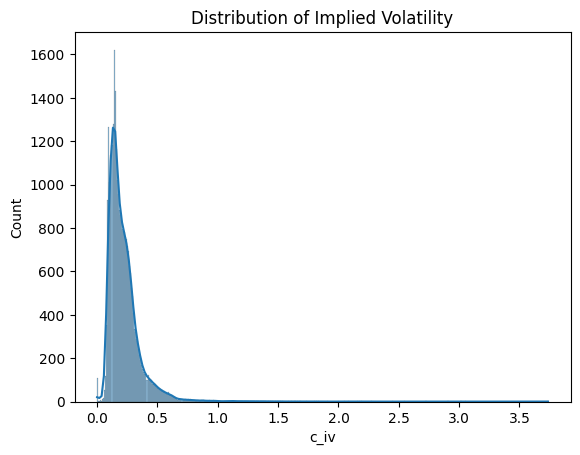

In [295]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(options_data_clean['c_iv'], kde=True)
plt.title('Distribution of Implied Volatility')
plt.show()

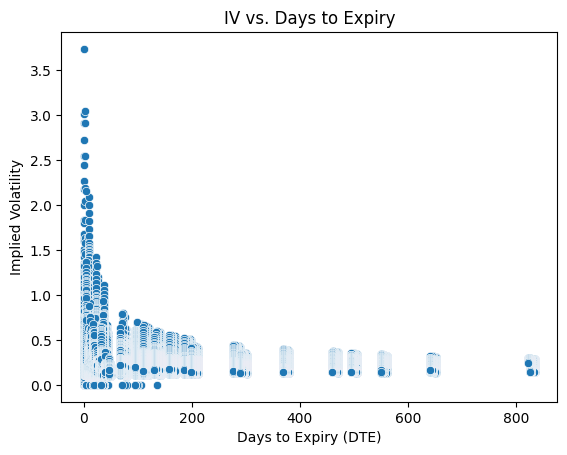

In [296]:
sns.scatterplot(x=options_data_clean['dte'], y=options_data_clean['c_iv'])
plt.title("IV vs. Days to Expiry")
plt.xlabel("Days to Expiry (DTE)")
plt.ylabel("Implied Volatility")
plt.show()

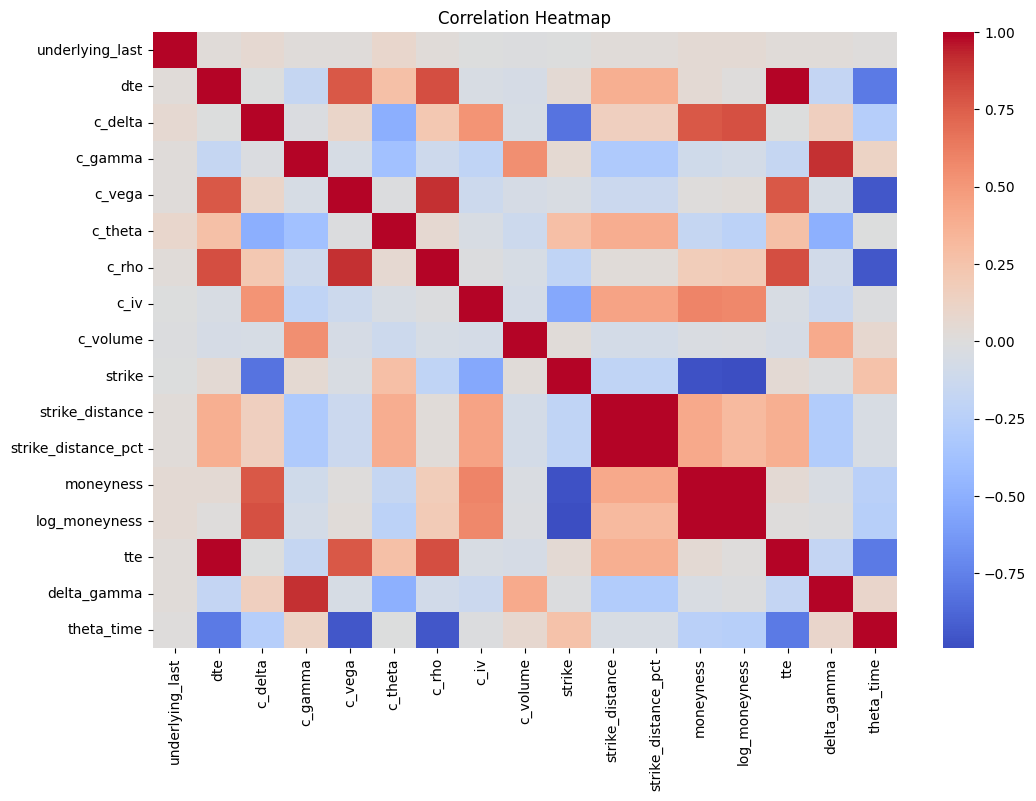

In [297]:
# Drop non-numeric or irrelevant columns
numeric_df = options_data_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

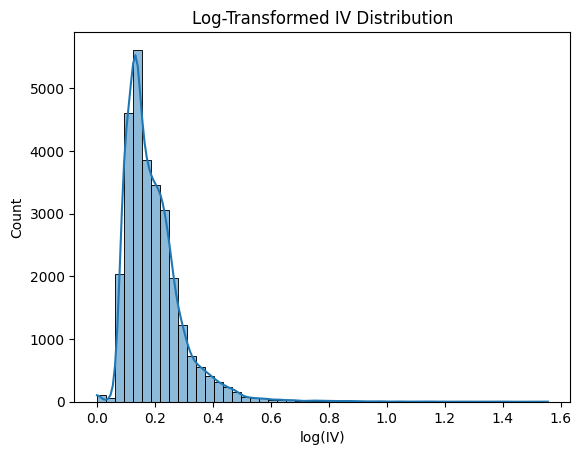

In [316]:
options_data_clean['log_c_iv'] = np.log1p(options_data_clean['c_iv']) 
sns.histplot(options_data_clean['log_c_iv'], bins=50, kde=True)
plt.title("Log-Transformed IV Distribution")
plt.xlabel("log(IV)")
plt.show()

In [299]:
options_data_clean

,underlying_last,dte,c_delta,c_gamma,c_vega,c_theta,c_rho,c_iv,c_volume,strike,strike_distance,strike_distance_pct,moneyness,log_moneyness,tte,delta_gamma,theta_time,log_c_iv
0,451.85,0.00,0.95299,0.04262,0.01954,-0.04563,0.00829,0.11477,2407.0,448.0,3.9,0.009,1.008594,0.008557,0.000000,0.040616,-0.000000,0.108648
1,451.85,0.00,0.29441,1.16447,0.06972,-0.05499,0.00274,0.01498,134982.0,452.0,0.1,0.000,0.999668,-0.000332,0.000000,0.342832,-0.000000,0.014869
2,451.85,0.00,0.05114,0.14827,0.02094,-0.01562,-0.00002,0.03466,209154.0,453.0,1.1,0.003,0.997461,-0.002542,0.000000,0.007583,-0.000000,0.034073
3,451.85,0.00,0.01411,0.03710,0.00719,-0.00529,0.00039,0.04878,71909.0,454.0,2.1,0.005,0.995264,-0.004747,0.000000,0.000523,-0.000000,0.047628
4,451.85,0.00,0.01091,0.02065,0.00577,-0.00513,-0.00020,0.06738,24042.0,455.0,3.1,0.007,0.993077,-0.006947,0.000000,0.000225,-0.000000,0.065207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29946,446.56,823.04,0.84861,0.00121,1.41765,-0.01921,3.09987,0.25837,1.0,315.0,131.6,0.295,1.417651,0.349001,2.254904,0.001027,-0.043317,0.229817
29947,446.56,823.04,0.84295,0.00126,1.46443,-0.01911,3.21388,0.25347,12.0,320.0,126.6,0.283,1.395500,0.333253,2.254904,0.001062,-0.043091,0.225916
29948,446.56,823.04,0.83515,0.00135,1.52637,-0.01935,3.33275,0.25100,2.0,325.0,121.6,0.272,1.374031,0.317749,2.254904,0.001127,-0.043632,0.223943
29949,446.56,823.04,0.82667,0.00149,1.58782,-0.02033,3.44288,0.24902,7.0,330.0,116.6,0.261,1.353212,0.302481,2.254904,0.001232,-0.045842,0.222359


## Split feature and target sets

In [300]:
# Prepare features and target
y = options_data_clean['log_c_iv']
X = options_data_clean.drop(['c_iv', 'log_c_iv'], axis = 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [301]:
X.columns

Index(['underlying_last', 'dte', 'c_delta', 'c_gamma', 'c_vega', 'c_theta',
       'c_rho', 'c_volume', 'strike', 'strike_distance', 'strike_distance_pct',
       'moneyness', 'log_moneyness', 'tte', 'delta_gamma', 'theta_time'],
      dtype='object')

## Normalize Features

In [313]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


## Train Random Forest Regression Model

In [314]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Basic Random Forest model
rf_basic = RandomForestRegressor(n_estimators=100, random_state=42)
rf_basic.fit(X_train_scaled, y_train)

# Make predictions
y_pred_basic = rf_basic.predict(X_test_scaled)

## Model Evaluation scores

In [315]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_basic)
mse = mean_squared_error(y_test, y_pred_basic)
r_squared = r2_score(y_test, y_pred_basic)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r_squared)

MAE: 0.02079179682854572
MSE: 0.001434640619374428
R2: 0.8677609169581517


In [305]:
# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_basic.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importances)


Feature Importances:
                Feature  Importance
8                strike    0.341474
6                 c_rho    0.132362
3               c_gamma    0.128142
4                c_vega    0.088512
11            moneyness    0.083483
12        log_moneyness    0.069691
2               c_delta    0.052290
5               c_theta    0.026981
15           theta_time    0.025006
1                   dte    0.016734
13                  tte    0.013837
14          delta_gamma    0.008034
9       strike_distance    0.006486
10  strike_distance_pct    0.003527
0       underlying_last    0.002610
7              c_volume    0.000832


### Hyperparameter tuning with GridSearchCV

In [306]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use a smaller subset for faster grid search
X_subset = X_train_scaled[:1000]
y_subset = y_train[:1000]

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_subset, y_subset)

print("\nBest parameters:", grid_search.best_params_)

# Train the model with best parameters
rf_tuned = RandomForestRegressor(**grid_search.best_params_, random_state=42)
rf_tuned.fit(X_train_scaled, y_train)

# Make predictions with tuned model
y_pred_tuned = rf_tuned.predict(X_test_scaled)


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [307]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
r_squared = r2_score(y_test, y_pred_tuned)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r_squared)

MAE: 0.020506358983685292
MSE: 0.001441409083249533
R2: 0.867137028686512


Text(0, 0.5, 'Predicted log IV')

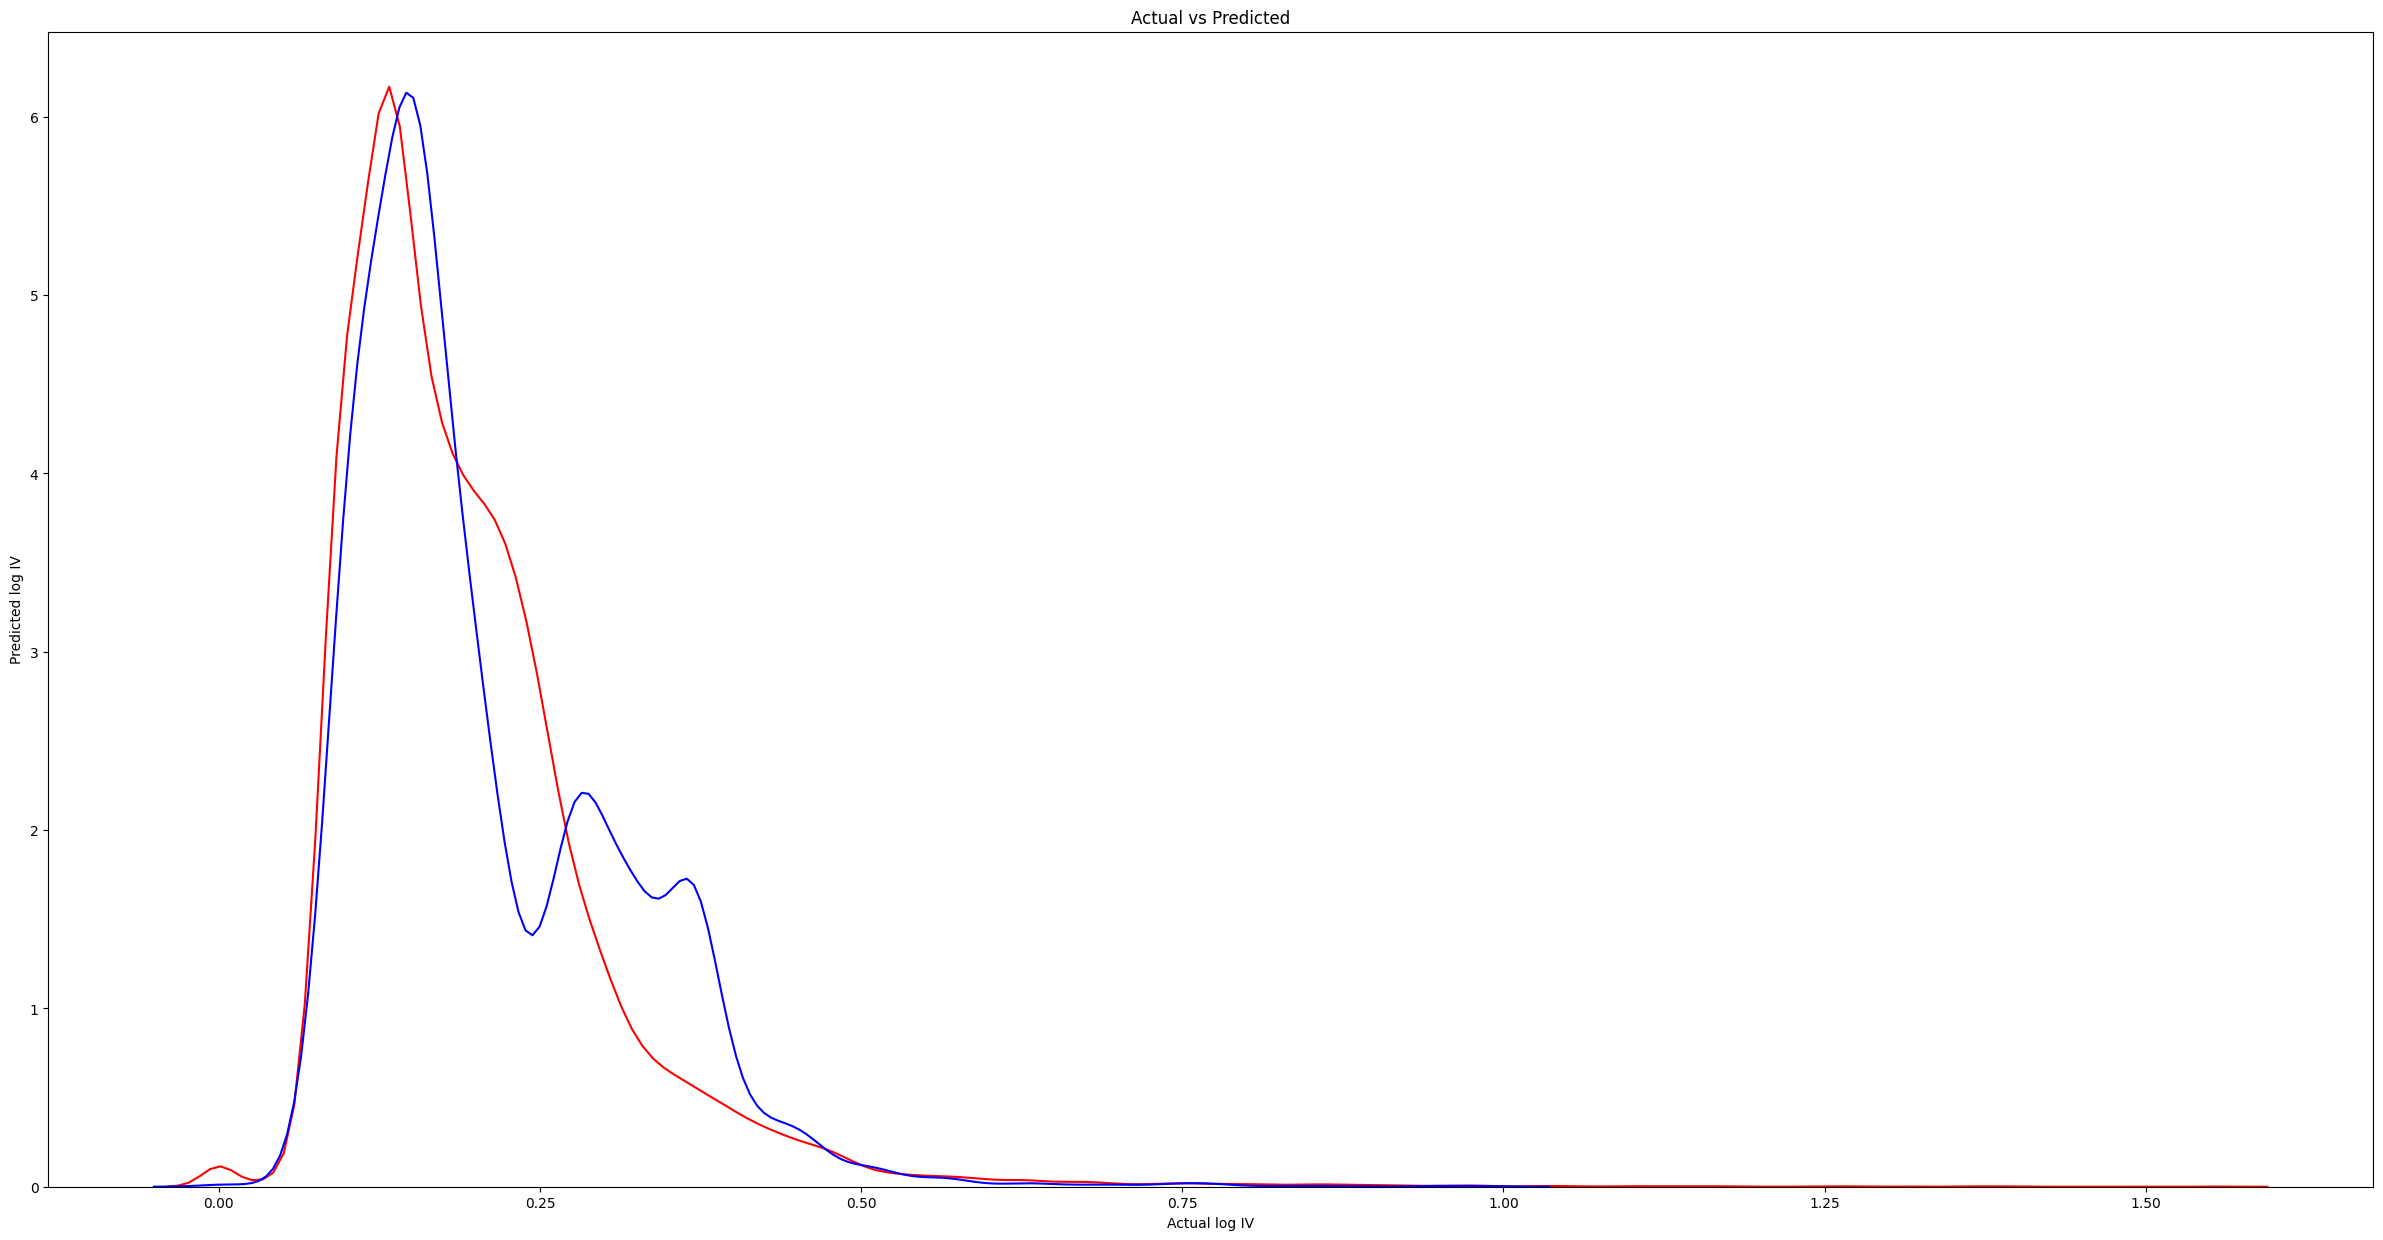

In [309]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(30,15))
ax1 = sns.distplot(y, hist=False, color='r', label="Actual Values")
sns.distplot(y_pred_basic, hist=False, color='b', label="Predicted Values")
plt.title('Actual vs Predicted')
plt.xlabel('Actual log IV')
plt.ylabel('Predicted log IV')

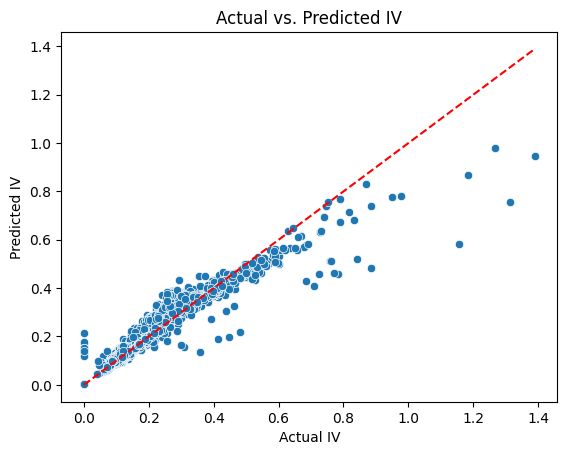

In [310]:
sns.scatterplot(x=y_test, y=y_pred_basic)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual IV")
plt.ylabel("Predicted IV")
plt.title("Actual vs. Predicted IV")
plt.show()

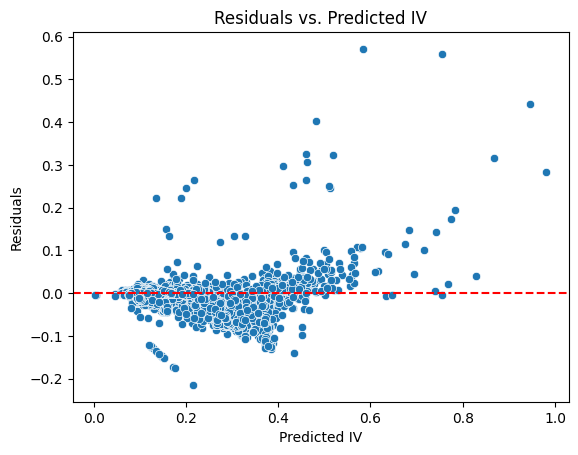

In [311]:
residuals = y_test - y_pred_basic

sns.scatterplot(x=y_pred_basic, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted IV")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted IV")
plt.show()